In [35]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [36]:
df_DE = df[df['job_title_short'] == 'Data Engineer'].copy()

df_DE

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,NaN,NaN,NaN,ALPHA Augmented Services,"[python, sql, c#, azure, airflow, dax, docker,...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"[python, c++, java, matlab, aws, tensorflow, k...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,NaN,NaN,NaN,Kristina Daniel,"[bash, python, oracle, aws, ansible, puppet, j...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."
5,Data Engineer,GCP Data Engineer,Anywhere,via ZipRecruiter,Contractor and Temp work,True,Georgia,2023-11-07 14:01:59,False,False,United States,NaN,NaN,NaN,smart folks inc,"[python, sql, gcp]","{'cloud': ['gcp'], 'programming': ['python', '..."
7,Data Engineer,Data Engineer,Anywhere,via LinkedIn,Full-time,True,Romania,2023-12-07 13:40:49,False,False,Romania,NaN,NaN,NaN,Zitec,"[sql, nosql, gcp, azure, aws, bigquery, databr...","{'cloud': ['gcp', 'azure', 'aws', 'bigquery', ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785729,Data Engineer,Data Engineer Marketing Intelligence,Jerman,melalui BeBee Deutschland,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,NaN,NaN,NaN,IU Internationale Hochschule,NaN,NaN
785730,Data Engineer,"Data Center Engineering Operations Engineer , ...","Bangkok, Thailand",melalui LinkedIn,Pekerjaan tetap,False,Thailand,2023-03-12 06:37:47,False,False,Thailand,NaN,NaN,NaN,Amazon Web Services (AWS),"[excel, word, outlook]","{'analyst_tools': ['excel', 'word', 'outlook']}"
785731,Data Engineer,Data Engineer,"Overland Park, Kansas, Amerika Serikat",melalui LinkedIn,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:17,False,False,Sudan,NaN,NaN,NaN,Shamrock Trading Corporation,"[nosql, mongodb, mongodb, python, elasticsearc...","{'analyst_tools': ['excel'], 'cloud': ['aws', ..."
785732,Data Engineer,Data Engineer (f/m/d),"Heidelberg, Jerman",melalui Top County Careers,Pekerjaan tetap,False,Germany,2023-03-13 06:18:59,False,False,Germany,NaN,NaN,NaN,Heidelberg Materials,"[python, c#, java, scala, sql, postgresql, sql...","{'cloud': ['azure', 'databricks'], 'databases'..."


In [37]:
df_DE['job_posted_month_no'] = df_DE['job_posted_date'].dt.month

df_DE_exploded = df_DE.explode('job_skills')

df_DE_exploded.pivot_table(index='job_posted_month_no', columns='job_skills', values='job_title_short', aggfunc='count', fill_value=0)

job_skills,airflow,airtable,alteryx,angular,angular.js,ansible,apl,arch,asana,asp.net,...,webex,windows,wire,word,workfront,wrike,wsl,xamarin,yarn,zoom
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,2897,3,263,175,8,400,0,4,16,37,...,5,371,10,432,0,0,1,0,151,59
2,2132,2,195,112,6,313,0,4,8,30,...,5,319,7,321,0,0,1,5,103,33
3,2187,5,205,92,7,340,3,4,8,19,...,6,270,8,328,0,1,0,0,124,29
4,2162,4,179,158,2,298,2,1,6,19,...,5,252,6,261,0,0,0,2,97,21
5,1988,1,167,153,3,272,0,4,7,9,...,1,232,5,233,0,0,0,1,93,23
6,2254,3,235,141,5,320,3,0,8,20,...,4,274,11,275,1,0,3,0,100,28
7,2015,9,208,99,0,268,0,0,9,18,...,7,302,6,246,2,0,0,0,76,28
8,2111,16,201,127,1,278,2,6,4,25,...,2,312,9,272,1,0,1,0,121,23
9,1812,5,186,91,4,259,1,2,4,13,...,3,276,9,256,0,0,4,1,101,20


In [38]:
df_DE['job_posted_month_no'] = df_DE['job_posted_date'].dt.month

df_DE_exploded = df_DE.explode('job_skills')

df_DE_pivot.loc['Total'] = df_DE_pivot.sum()

df_DE_pivot = df_DE_pivot[df_DE_pivot.loc['Total'].sort_values(ascending=False).index]

df_DE_pivot



job_skills,sql,python,aws,azure,spark,java,kafka,hadoop,scala,databricks,...,shogun,fastify,workfront,dlib,ember.js,homebrew,asp.netcore,linode,chainer,dingtalk
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
January,12987,12426,6924,7138,6567,4246,3687,3533,3517,3002,...,2,0,0,0,0,0,0,0,0,0
February,9792,9378,5446,5278,4948,3300,2809,2774,2625,2272,...,1,0,0,0,0,0,0,0,0,0
March,9831,9410,5580,5283,4764,3223,2689,2592,2621,2378,...,0,0,0,0,0,0,0,0,0,0
April,8975,8670,5012,4901,4316,2931,2329,2340,2373,2170,...,0,0,0,0,0,3,0,0,1,0
May,8411,8169,4768,4466,3991,2725,2166,2195,2132,2034,...,0,0,0,0,0,0,1,0,0,0
June,9713,9216,5280,5091,4654,3092,2516,2468,2464,2317,...,0,0,1,0,0,0,0,0,0,0
July,9032,8493,5015,4857,4044,2757,2296,2235,2213,2161,...,0,0,2,2,0,0,0,0,0,0
August,9565,9016,5330,5070,4436,2961,2468,2421,2427,2310,...,0,0,1,0,0,0,1,0,0,0
September,8663,8213,4612,4646,3902,2584,2088,2024,2070,2198,...,1,0,0,0,0,0,0,1,0,0


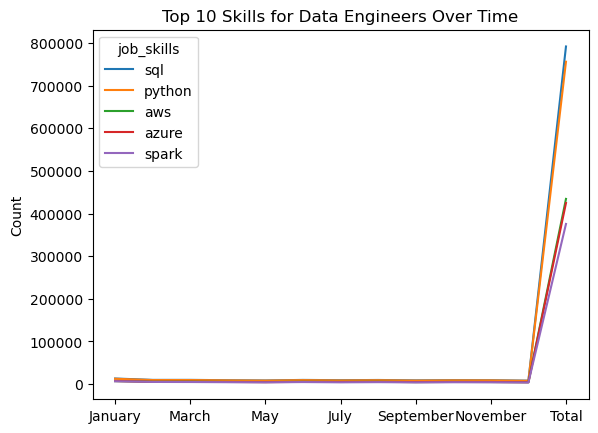

In [39]:
df_DE_pivot.iloc[:, :5].plot(kind="line")

plt.title('Top 10 Skills for Data Engineers Over Time')
plt.ylabel('Count')
plt.xlabel('')
plt.show()


In [41]:
df_DE_pivot = df_DE_pivot.reset_index()
df_DE_pivot['job_posted_month_no'] = df_DE_pivot['job_posted_month_no'].apply({lambda x: pd.to_datetime(x, format = '%m').strftime('%B') if x != 'Total' else x})
df_DE_pivot = df_DE_pivot.set_index('job_posted_month_no')
df_DE_pivot = df_DE_pivot.drop(columns = 'job_posted_month_no')

df_DE_pivot.iloc[:, :5].plot(kind="line")

plt.title('Top 10 Skills for Data Engineers Over Time')
plt.ylabel('Count')
plt.xlabel('Month')
plt.show()

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [43]:
df_DE_pivot = df_DE_pivot.reset_index()

df_DE_pivot['job_posted_month_no'] = (
    df_DE_pivot['job_posted_month_no']
    .apply(
        lambda x: pd.to_datetime(str(int(x)), format='%m').strftime('%B')
    )
)

df_DE_pivot = df_DE_pivot.set_index('job_posted_month_no')

df_DE_pivot.iloc[:, :5].plot(kind='line')

plt.title('Top 10 Skills for Data Engineers Over Time')
plt.ylabel('Count')
plt.xlabel('Month')

plt.show()

ValueError: cannot insert level_0, already exists